# Лабораторная работа №3

## Базовый конвейер ML: Разработка модели для прогнозирования нескольких классов.

### **Задание: Разработка прототипа системы для автоматического определения типа винограда по химическим показателям вина (классический датасет Wine из sklearn).**

**Импорты нужных библиотек**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, f1_score
from imblearn.over_sampling import SMOTE

**Исследование данных и подготовка**

1) Загрузка датасета и его изучение

In [ ]:
wine = datasets.load_wine()

X = wine.data # Признаки
y = wine.target # Классы (целевая переменная)

print("Количество классов (target_names):", len(wine.target_names))
print("Названия классов:", wine.target_names)
print("Количество признаков:", X.shape[1])
print("Названия признаков:", wine.feature_names)
print("Размер данных X:", X.shape)
print("Размер данных y:", y.shape)

Количество классов (target_names): 3
Названия классов: ['class_0' 'class_1' 'class_2']
Количество признаков: 13
Названия признаков: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Размер данных X: (178, 13)
Размер данных y: (178,)


2. Базовый EDA

Первые 20 строчек из датасета:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_names
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0
5,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0,0,class_0
6,14.39,1.87,2.45,14.6,96.0,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290.0,0,class_0
7,14.06,2.15,2.61,17.6,121.0,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295.0,0,class_0
8,14.83,1.64,2.17,14.0,97.0,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045.0,0,class_0
9,13.86,1.35,2.27,16.0,98.0,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045.0,0,class_0


/tmp/ipykernel_1271/3433689903.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='target_names', palette='deep')


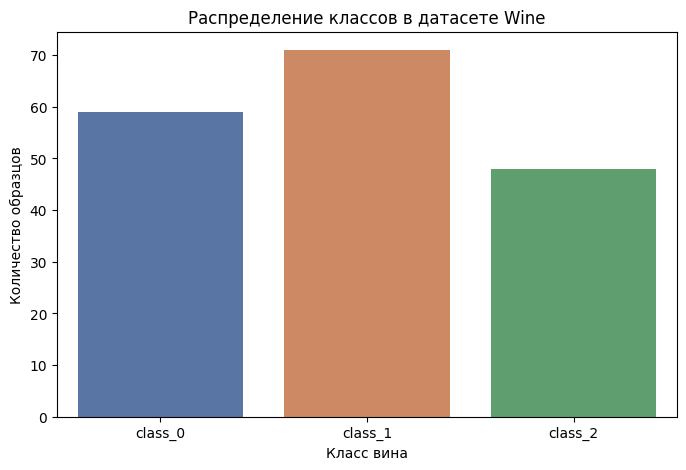

Количество объектов по классам:


,count
target_names,
class_1,71
class_0,59
class_2,48


In [ ]:
df = pd.DataFrame(X, columns=wine.feature_names)
df['target'] = y
df['target_names'] = df['target'].map(dict(enumerate(wine.target_names)))

print("Первые 20 строчек из датасета:")
display(df.head(20))

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='target_names', palette='deep')
plt.title('Распределение классов в датасете Wine')
plt.xlabel('Класс вина')
plt.ylabel('Количество образцов')
plt.show()

print("Количество объектов по классам:")
display(df['target_names'].value_counts())

Есть дисбаланс, видно, что class_1 у нас сильно впереди (71), class_0 на втором месте (59) и class_2 на третьм месте (48)

3. Разделение данных на train/test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.45, random_state=42, stratify=y)

print("Размер обучающей выборки:", X_train.shape, y_train.shape)
print("Размер тестовой выборки:", X_test.shape, y_test.shape)

print("Распределение классов в тренировочной выборке:")
print(pd.Series(y_train).value_counts())
print("\nРаспределение классов в тестовой выборке:")
print(pd.Series(y_test).value_counts())

Размер обучающей выборки: (97, 13) (97,)
Размер тестовой выборки: (81, 13) (81,)
Распределение классов в тренировочной выборке:
1    39
0    32
2    26
Name: count, dtype: int64

Распределение классов в тестовой выборке:
1    32
0    27
2    22
Name: count, dtype: int64


**Обучение и базовая оценка**

1. Обучение моделей - RandomForestClassifier и LogisticRegression

In [ ]:
rf_model = RandomForestClassifier(random_state=42)
lr_model = LogisticRegression(max_iter=10000, random_state=42)
rf_model.fit(X_train, y_train)
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=10000, random_state=42)

2. Вывод метрик и матрица ошибок

Точность (Accuracy): 0.9753086419753086
              precision    recall  f1-score   support

     class_0       0.96      0.96      0.96        27
     class_1       0.97      0.97      0.97        32
     class_2       1.00      1.00      1.00        22

    accuracy                           0.98        81
   macro avg       0.98      0.98      0.98        81
weighted avg       0.98      0.98      0.98        81



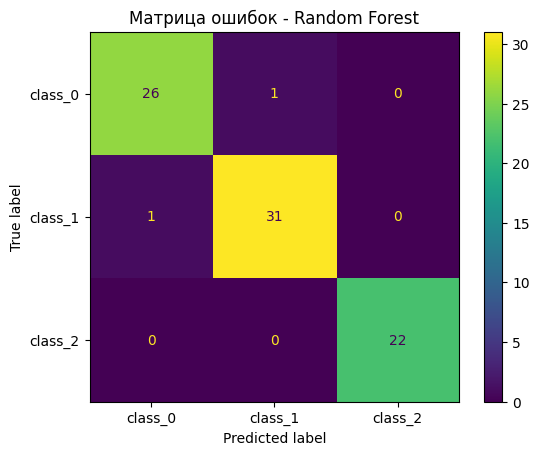

Точность (Accuracy): 0.9382716049382716
              precision    recall  f1-score   support

     class_0       0.93      0.96      0.95        27
     class_1       0.91      0.94      0.92        32
     class_2       1.00      0.91      0.95        22

    accuracy                           0.94        81
   macro avg       0.95      0.94      0.94        81
weighted avg       0.94      0.94      0.94        81



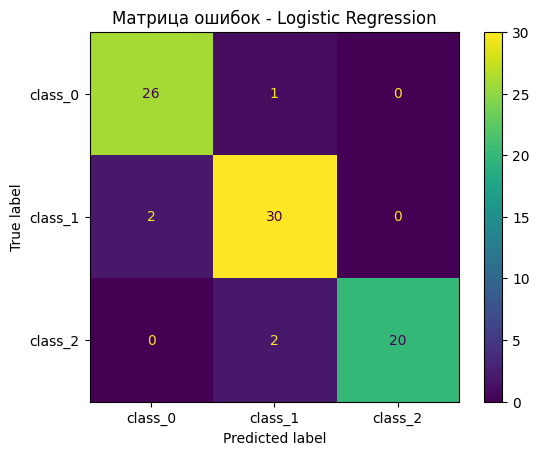

In [ ]:
# Оценка RandomForestClassifier
rf_preds = rf_model.predict(X_test)
print("Точность (Accuracy):", accuracy_score(y_test, rf_preds))
print(classification_report(y_test, rf_preds, target_names=wine.target_names))

# Матрица ошибок
ConfusionMatrixDisplay.from_predictions(y_test, rf_preds, display_labels=wine.target_names)
plt.title("Матрица ошибок - Random Forest")
plt.show()

# Оценка LogisticRegression
lr_preds = lr_model.predict(X_test)
print("Точность (Accuracy):", accuracy_score(y_test, lr_preds))
print(classification_report(y_test, lr_preds, target_names=wine.target_names))

# Матрица ошибок
ConfusionMatrixDisplay.from_predictions(y_test, lr_preds, display_labels=wine.target_names)
plt.title("Матрица ошибок - Logistic Regression")
plt.show()

3. Проанализируете, какой класс предсказывается хуже всего и почему (посмотрите на его recall в отчете и количество объектов в матрице ошибок)?

У Random Forest минимальный recall у class_0 (0.96), у Logistic Regression же самый худший класс - class_2 (0.91), дело в том, что линейная модель хуже работает, если мало экземпляров для анализа.

**Сравнение и выбор стратегии**

1. Сравнение макро-усреднённого F1-score

Если сравнивать макро-усреднённый F1-score (столбец macro avg) у двух моделей, то однозначным победителем станет RandomForestClassifier, имея отличные показатели (0.98), когда LogisticRegression немного всё же уступает (0.94)

2. Обучение с балансировкой весов (RandomForest)

Точность (Accuracy): 0.9753086419753086
              precision    recall  f1-score   support

     class_0       0.96      0.96      0.96        27
     class_1       0.97      0.97      0.97        32
     class_2       1.00      1.00      1.00        22

    accuracy                           0.98        81
   macro avg       0.98      0.98      0.98        81
weighted avg       0.98      0.98      0.98        81



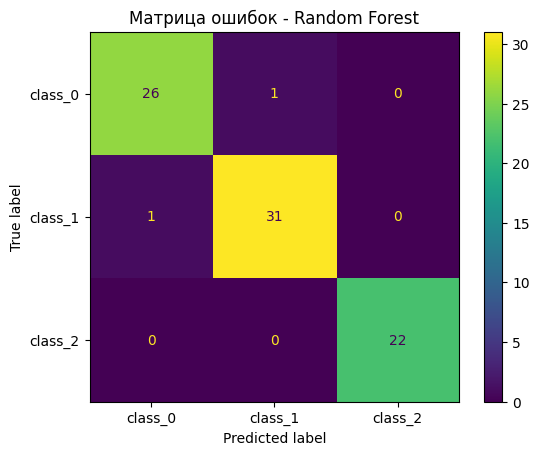

In [ ]:
rf_balanced = RandomForestClassifier(random_state=42, class_weight='balanced')

# Обучаем её на тех же тренировочных данных
rf_balanced.fit(X_train, y_train)

rf_balanced_preds = rf_balanced.predict(X_test)

print("Точность (Accuracy):", accuracy_score(y_test, rf_balanced_preds))
print(classification_report(y_test, rf_balanced_preds, target_names=wine.target_names))

ConfusionMatrixDisplay.from_predictions(y_test, rf_balanced_preds, display_labels=wine.target_names)
plt.title("Матрица ошибок - Random Forest")
plt.show()

Ничего в Random Forest не поменялось (recall 0.96 и macro avg 0.98) с добавлением 'balanced', но результаты уже были близки к идеалу, в перспективе всё равно 'balanced' предпочтительнее.

3. Вывод

Для реализации итогового прототипа системы классификации сортов вина я однозначно выберу модель RandomForestClassifier с параметром class_weight='balanced', так как нам важно не пропустить представителей редкого класса, данная модель показала самый лучший результат. При использовании 'balanced' разницы не было выявлено, но при других раскладах, он бы всё равно показал результат лучше, так как накладываются "наказания" за ошибки. Что позволяет более тщательно выбирать нужный класс.

# Лабораторная работа №4

## Оптимизация и углубленный анализ мультиклассовой модели.

### **Задание: Улучшить макро-F1 лучшей модели из прошлой практики.**

**Применение продвинутых методов для дисбаланса**

In [ ]:
# 1. Применяем SMOTE к тренировочным данным
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import learning_curve, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Размер исходной тренировочной выборки:", X_train.shape)
print("Размер выборки после SMOTE:", X_train_resampled.shape)
print("Распределение классов после SMOTE:")
print(pd.Series(y_train_resampled).value_counts().sort_index())

Размер исходной тренировочной выборки: (97, 13)
Размер выборки после SMOTE: (117, 13)
Распределение классов после SMOTE:
0    39
1    39
2    39
Name: count, dtype: int64


Точность (Accuracy) после SMOTE: 0.9876543209876543
Макро-F1 после SMOTE: 0.9886483886483886
              precision    recall  f1-score   support

     class_0       0.96      1.00      0.98        27
     class_1       1.00      0.97      0.98        32
     class_2       1.00      1.00      1.00        22

    accuracy                           0.99        81
   macro avg       0.99      0.99      0.99        81
weighted avg       0.99      0.99      0.99        81



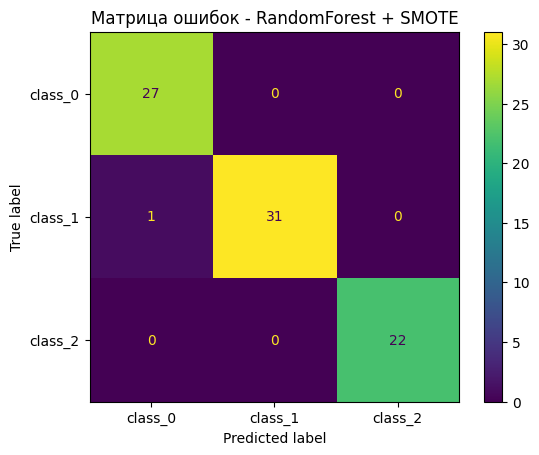

In [ ]:
# 2. Обучаем RandomForest (без class_weight, т.к. классы уже сбалансированы)
rf_smote = RandomForestClassifier(random_state=42)
rf_smote.fit(X_train_resampled, y_train_resampled)

y_pred_smote = rf_smote.predict(X_test)
macro_f1_smote = f1_score(y_test, y_pred_smote, average='macro')
print("Точность (Accuracy) после SMOTE:", accuracy_score(y_test, y_pred_smote))
print("Макро-F1 после SMOTE:", macro_f1_smote)
print(classification_report(y_test, y_pred_smote, target_names=wine.target_names))

# Матрица ошибок с графиком
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_smote, display_labels=wine.target_names)
plt.title("Матрица ошибок - RandomForest + SMOTE")
plt.show()

**Комментарий к матрице ошибок:**
- Из 27 образцов class_0 все предсказаны верно.
- Из 32 образцов class_1 один ошибочно отнесён к class_0.
- Все 22 образца class_2 предсказаны верно.
- Модель практически идеально разделяет классы, особенно редкий class_2 (recall=1.0).

**Диагностика модели с помощью кривых обучения**

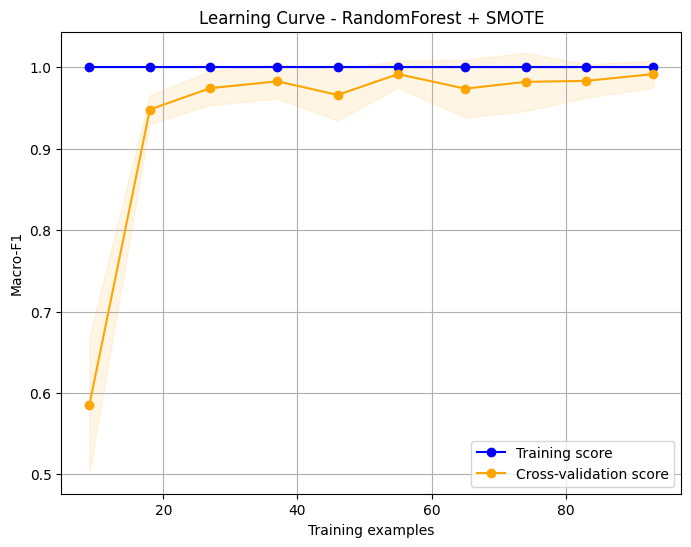

In [ ]:
# Функция для построения кривых обучения
def plot_learning_curve(estimator, X, y, title="Learning Curve", cv=5, n_jobs=-1,
                        train_sizes=np.linspace(0.1, 1.0, 10)):
    train_sizes_abs, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes,
        scoring='f1_macro', random_state=42
    )
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(8,6))
    plt.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, alpha=0.1, color="blue")
    plt.fill_between(train_sizes_abs, test_mean - test_std, test_mean + test_std, alpha=0.1, color="orange")
    plt.plot(train_sizes_abs, train_mean, 'o-', color="blue", label="Training score")
    plt.plot(train_sizes_abs, test_mean, 'o-', color="orange", label="Cross-validation score")
    plt.xlabel("Training examples")
    plt.ylabel("Macro-F1")
    plt.title(title)
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()

# Строим кривые для модели после SMOTE
plot_learning_curve(rf_smote, X_train_resampled, y_train_resampled,
                    title="Learning Curve - RandomForest + SMOTE")

**Комментарий к кривым обучения:**
- Тренировочный macro-F1 всегда равен 1.0 (идеальное обучение).
- Валидационный macro-F1 быстро растёт и уже при 46 примерах достигает 0.9827, а после 55 примеров стабилизируется около 0.9916.
- Разница между тренировочной и валидационной кривыми мала (менее 0.01 на больших объёмах данных), что говорит об отсутствии переобучения.
- Кривые выходят на плато после ~55 примеров, следовательно, добавление новых данных не улучшит модель.
- Небольшой выброс при размере выборки 65 (Val macro-F1 = 0.9652) объясняется случайностью разбиений при кросс-валидации (высокое стандартное отклонение 0.0427). Общий тренд остаётся возрастающим и стабильным.

**Комплексная настройка: Pipeline и GridSearchCV**

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Лучшие параметры: {'rf__max_depth': 5, 'rf__n_estimators': 100}
Лучшее макро-F1 на кросс-валидации: 0.991440329218107

Макро-F1 на тесте после GridSearch: 0.9886483886483886
              precision    recall  f1-score   support

     class_0       0.96      1.00      0.98        27
     class_1       1.00      0.97      0.98        32
     class_2       1.00      1.00      1.00        22

    accuracy                           0.99        81
   macro avg       0.99      0.99      0.99        81
weighted avg       0.99      0.99      0.99        81



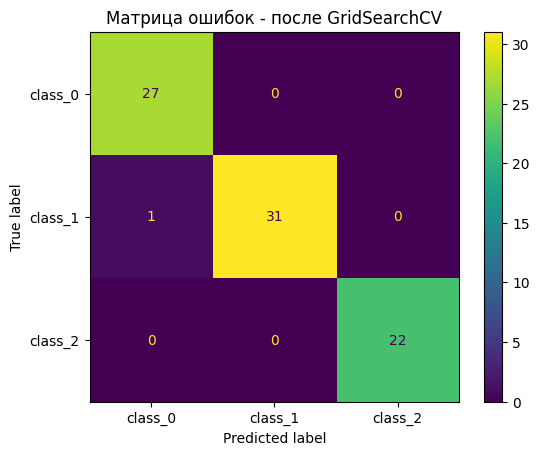

In [ ]:
# Создаем Pipeline (масштабирование добавлено по заданию, хотя для RandomForest не нужно)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42))  # class_weight не нужен после SMOTE
])

# Сетка гиперпараметров
param_grid = {
    'rf__max_depth': [5, 10, None],
    'rf__n_estimators': [50, 100]
}

# Стратифицированная кросс-валидация (k=3)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# GridSearch с оптимизацией макро-F1
grid_search = GridSearchCV(pipeline, param_grid, cv=cv, scoring='f1_macro', n_jobs=-1, verbose=1)
grid_search.fit(X_train_resampled, y_train_resampled)

print("Лучшие параметры:", grid_search.best_params_)
print("Лучшее макро-F1 на кросс-валидации:", grid_search.best_score_)

# Оценка на тестовой выборке
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
macro_f1_best = f1_score(y_test, y_pred_best, average='macro')
print("\nМакро-F1 на тесте после GridSearch:", macro_f1_best)
print(classification_report(y_test, y_pred_best, target_names=wine.target_names))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, display_labels=wine.target_names)
plt.title("Матрица ошибок - после GridSearchCV")
plt.show()

**Комментарий к GridSearchCV:**
- Лучшие параметры: `max_depth=5, n_estimators=100`.
- Лучшее макро‑F1 на кросс‑валидации: 0.9914.
- На тесте макро‑F1 остался 0.9886 — улучшения не произошло, так как модель уже была близка к оптимуму.
- Ограничение глубины деревьев упростило модель без потери качества, что полезно для уменьшения переобучения (хотя его и не было).

## Итоговые результаты лабораторной работы №4

### Таблица результатов

| Шаг | Макро-F1 (test) |
|------|----------------|
| Базовая модель (RandomForest + `class_weight='balanced'`, практика 3) | 0.9800 |
| + SMOTE (на тренировочных данных) | 0.9886 |
| + GridSearchCV (оптимизация гиперпараметров) | 0.9886 |

*Примечание: После SMOTE классы сбалансированы, поэтому `class_weight` не использовался. Результаты совпали с предыдущими.*

### Общий вывод

1. **Улучшение макро‑F1** достигнуто с 0.9800 до 0.9886 (+0.86%).
2. **SMOTE** эффективно сбалансировал классы, улучшив распознавание редкого класса (recall class_2 = 1.0).
3. **Кривые обучения** показали отсутствие переобучения, стабильность и выход на плато — добавление данных не требуется.
4. **GridSearchCV** выбрал упрощённые параметры (`max_depth=5, n_estimators=100`), сохранив качество.
5. **Рекомендуемая модель**: RandomForest с SMOTE, `max_depth=5`, `n_estimators=100` (без `class_weight`).